In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from keras import (
    backend as K,
    losses,
    optimizers,
    layers,
    models,
    utils,
    callbacks
)

from pathlib import Path

In [5]:
data_dir = "/kaggle/input/datasets/pkdarabi/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification"



train_data = utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    color_mode="grayscale",
    image_size=(256,256),
    batch_size=64,
    seed=40
)

validation_data = utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    color_mode="grayscale",
    image_size=(256,256),
    batch_size=64,
    seed=42
)

Found 1129 files belonging to 10 classes.
Using 1017 files for training.
Found 1129 files belonging to 10 classes.
Using 112 files for validation.


2026-04-06 16:54:53.536583: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:

class_names = train_data.class_names
print("Class names:", class_names)

Class names: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


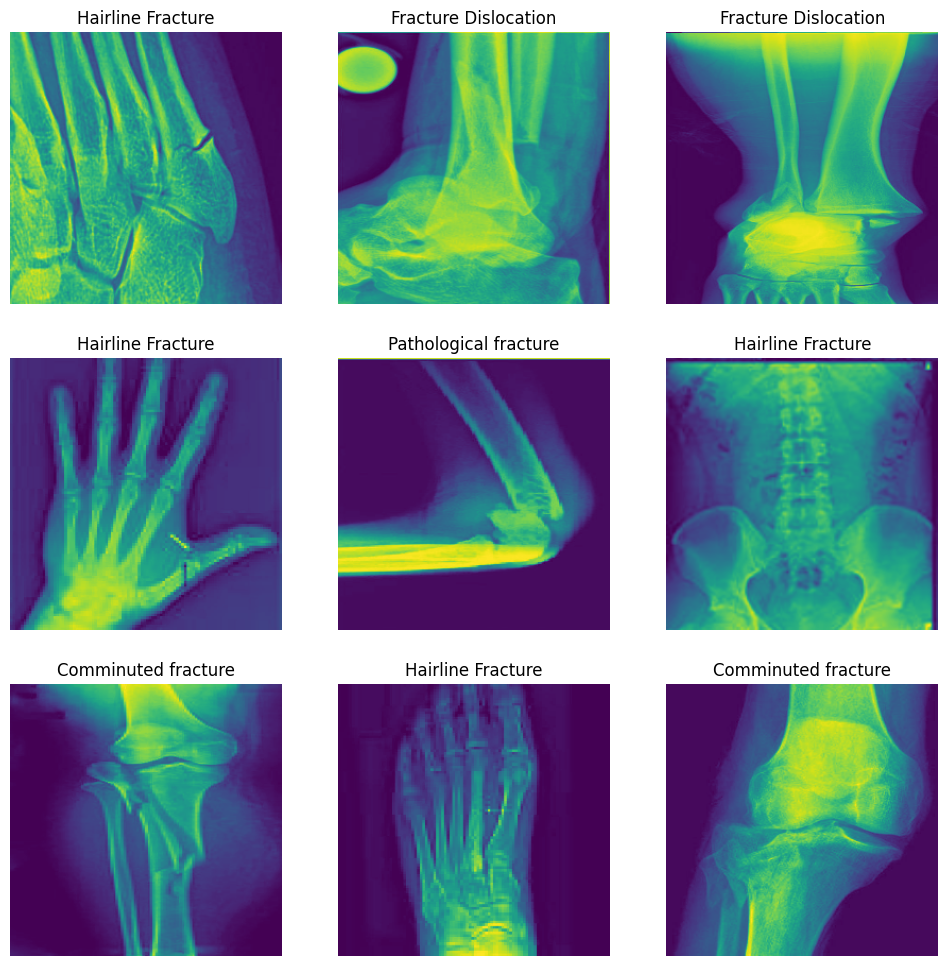

In [7]:
plt.figure(figsize=(12, 12))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [8]:
layers.Input(shape=(256, 256, 1))
model = keras.Sequential([
    layers.Input(shape=(256, 256, 1)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,167,882 (65.49 MB)

 Trainable params: 17,167,882 (65.49 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
for images, labels in train_data.take(1):
    print(images.shape)

(64, 256, 256, 1)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    "best_bone_fracture_model.keras",
    monitor='val_loss',
    save_best_only=True
)

In [12]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=25,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 92s 6s/step - accuracy: 0.1169 - loss: 2.4391 - val_accuracy: 0.1518 - val_loss: 2.2726 - learning_rate: 0.0010
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 88s 6s/step - accuracy: 0.1427 - loss: 2.2633 - val_accuracy: 0.1786 - val_loss: 2.2417 - learning_rate: 0.0010
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.1693 - loss: 2.2402 - val_accuracy: 0.2768 - val_loss: 2.0777 - learning_rate: 0.0010
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 85s 5s/step - accuracy: 0.2057 - loss: 2.1161 - val_accuracy: 0.3214 - val_loss: 1.9360 - learning_rate: 0.0010
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.3077 - loss: 1.9668 - val_accuracy: 0.4732 - val_loss: 1.6671 - learning_rate: 0.0010
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 85s 5s/step - accuracy: 0.3547 - loss: 1.7864 - val_accuracy: 0.5625 - val_loss: 1.4324 - learning_rate: 0.0010
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 85s 5s/step - accuracy: 0.4530 - loss: 1.5639 - val_accuracy: 

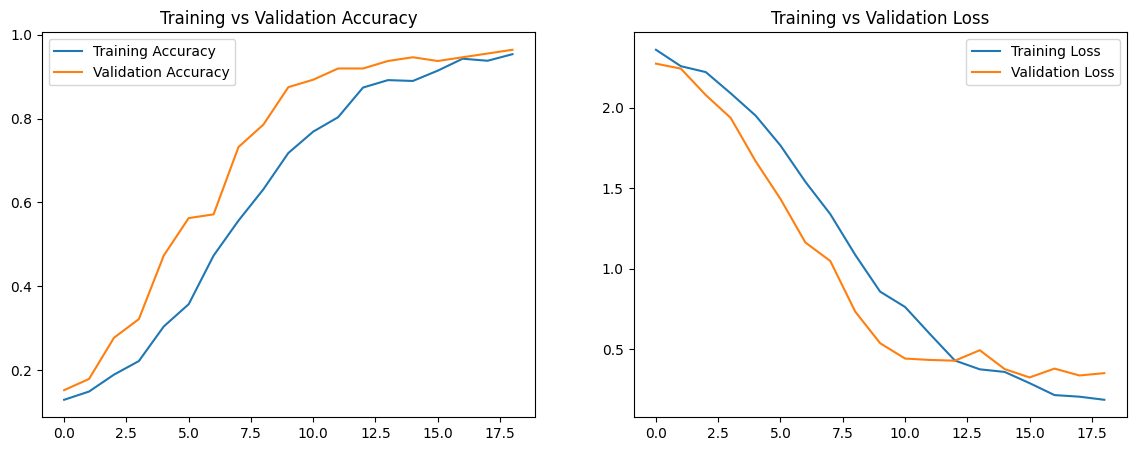

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()

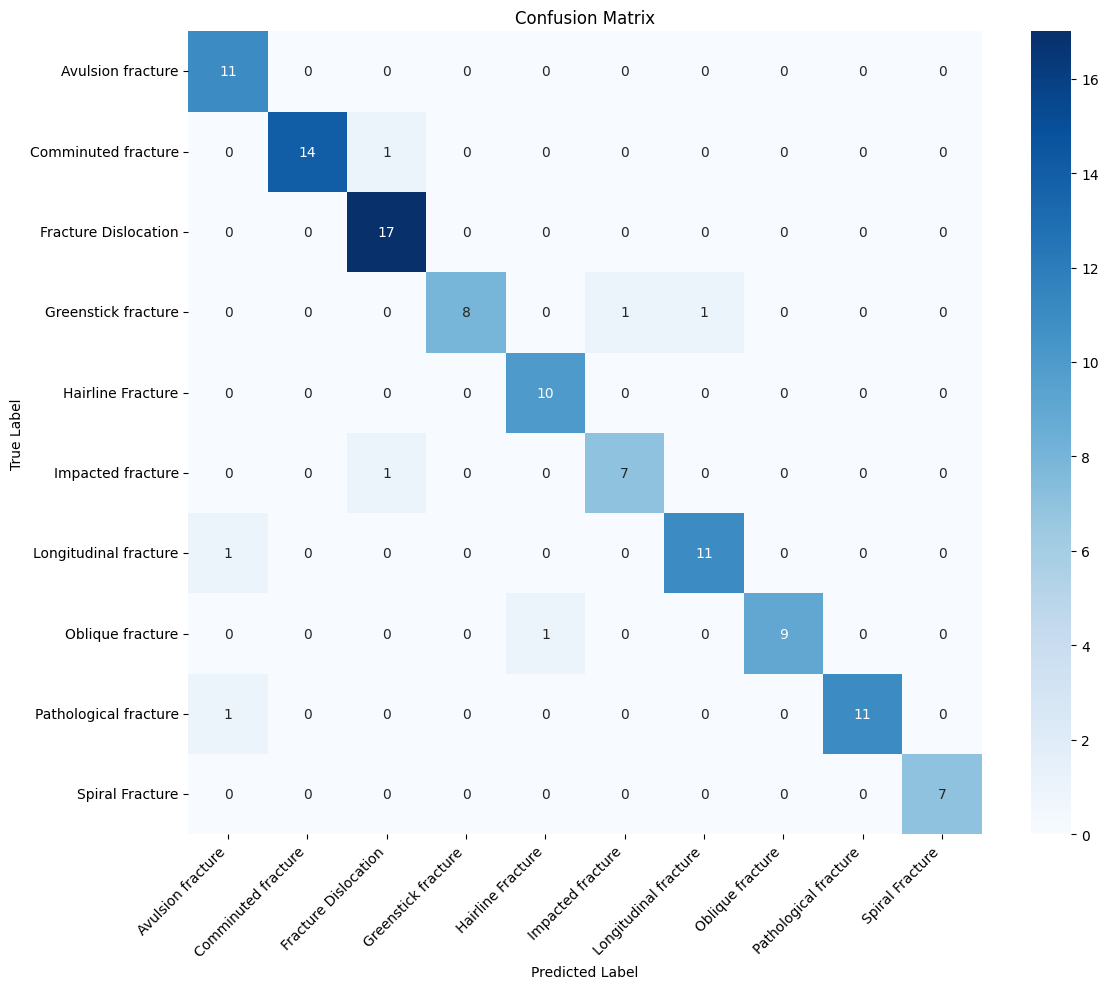

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_data:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

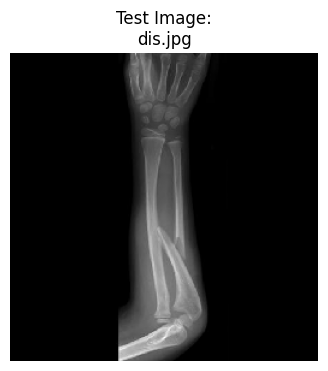

Image: /kaggle/input/datasets/yamenzedan/testimages/dis.jpg
Predicted class: Fracture Dislocation
Confidence: 99.92%
--------------------------------------------------


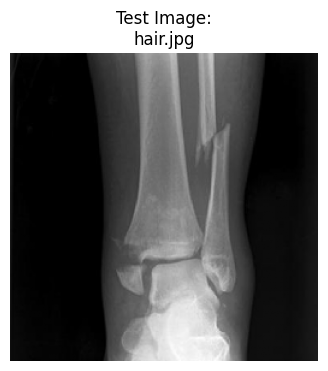

Image: /kaggle/input/datasets/yamenzedan/testimages/hair.jpg
Predicted class: Avulsion fracture
Confidence: 68.57%
--------------------------------------------------


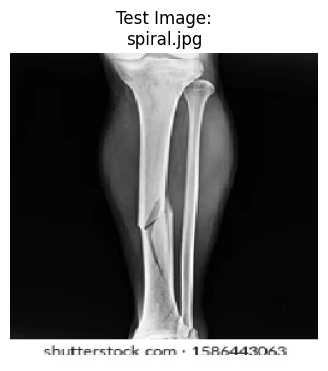

Image: /kaggle/input/datasets/yamenzedan/testimages/spiral.jpg
Predicted class: Spiral Fracture
Confidence: 95.71%
--------------------------------------------------


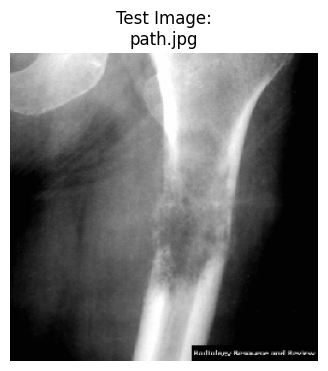

Image: /kaggle/input/datasets/yamenzedan/testimages/path.jpg
Predicted class: Pathological fracture
Confidence: 100.00%
--------------------------------------------------


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array


img_paths = [
    "/kaggle/input/datasets/yamenzedan/testimages/dis.jpg",
     "/kaggle/input/datasets/yamenzedan/testimages/hair.jpg",
    "/kaggle/input/datasets/yamenzedan/testimages/spiral.jpg",
    '/kaggle/input/datasets/yamenzedan/testimages/path.jpg'
]

for img_path in img_paths:
   
    img = load_img(
        img_path,
        color_mode="grayscale",
        target_size=(256, 256)
    )


    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title(f"Test Image:\n{img_path.split('/')[-1]}")
    plt.axis("off")
    plt.show()


    img_array = img_to_array(img)               
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_class_index = np.argmax(prediction, axis=1)[0]
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(prediction) * 100

    print("Image:", img_path)
    print("Predicted class:", predicted_class_name)
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 50)